In [1]:
# ================================
# CELL 1 : IMPORT LIBRARIES
# ================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_circles

In [2]:
# ================================
# CELL 2 : CREATE DATASET
# ================================

X, y = make_circles(
    n_samples=100,
    factor=0.1,
    noise=0.1,
    random_state=42
)

print(X.shape)
print(y.shape)

(100, 2)
(100,)


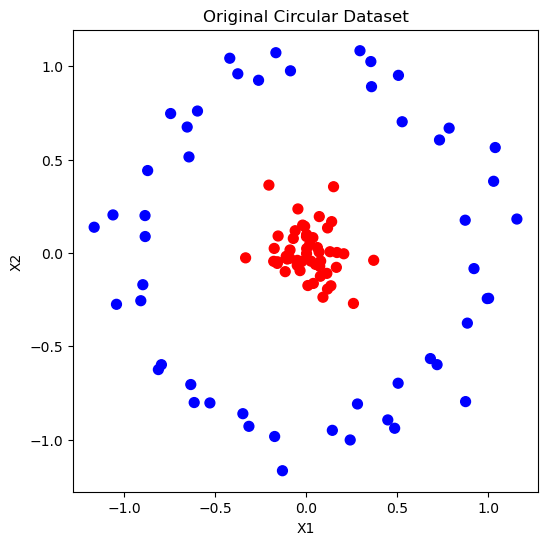

In [3]:
# ================================
# CELL 3 : PLOT ORIGINAL DATASET
# ================================

plt.figure(figsize=(6,6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    s=50,
    cmap='bwr'
)

plt.title("Original Circular Dataset")
plt.xlabel("X1")
plt.ylabel("X2")

plt.show()

In [4]:
# ================================
# CELL 4 : TRAIN TEST SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [5]:
# ================================
# CELL 5 : DECISION BOUNDARY FUNCTION
# ================================

zero_one_colourmap = ListedColormap(('blue', 'red'))

def plot_decision_boundary(X, y, clf, title):

    X1, X2 = np.meshgrid(
        np.arange(
            start=X[:, 0].min() - 1,
            stop=X[:, 0].max() + 1,
            step=0.01
        ),
        np.arange(
            start=X[:, 1].min() - 1,
            stop=X[:, 1].max() + 1,
            step=0.01
        )
    )

    predictions = clf.predict(
        np.array([X1.ravel(), X2.ravel()]).T
    ).reshape(X1.shape)

    plt.figure(figsize=(6,6))

    plt.contourf(
        X1,
        X2,
        predictions,
        alpha=0.75,
        cmap=zero_one_colourmap
    )

    for i, j in enumerate(np.unique(y)):
        plt.scatter(
            X[y == j, 0],
            X[y == j, 1],
            c=[zero_one_colourmap(i)],
            label=j
        )

    plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")

    plt.legend()

    plt.show()

In [6]:
# ================================
# CELL 6 : LINEAR SVM
# ================================

linear_classifier = SVC(kernel='linear')

linear_classifier.fit(X_train, y_train)

y_pred = linear_classifier.predict(X_test)

print(
    "Linear Kernel Accuracy :",
    accuracy_score(y_test, y_pred)
)

Linear Kernel Accuracy : 0.3


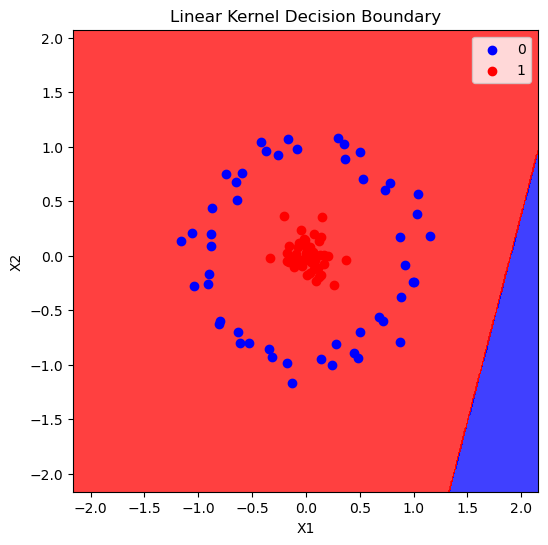

In [7]:
# ================================
# CELL 7 : LINEAR SVM GRAPH
# ================================

plot_decision_boundary(
    X,
    y,
    linear_classifier,
    "Linear Kernel Decision Boundary"
)

In [8]:
# ================================
# CELL 8 : 3D TRANSFORMATION FUNCTION
# ================================

def plot_3d_plot(X, y):

    r = np.exp(-(X ** 2).sum(1))

    fig = plt.figure(figsize=(8,6))

    ax = fig.add_subplot(
        111,
        projection='3d'
    )

    ax.scatter3D(
        X[:, 0],
        X[:, 1],
        r,
        c=y,
        s=100,
        cmap='bwr'
    )

    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('Z')

    plt.title("3D Transformation")

    plt.show()

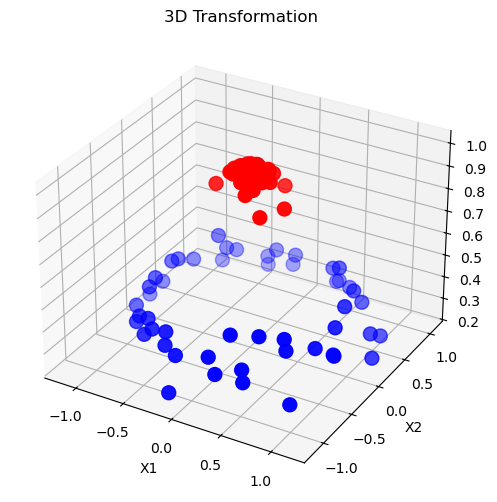

In [9]:
# ================================
# CELL 9 : 3D GRAPH
# ================================

plot_3d_plot(X, y)

In [10]:
# ================================
# CELL 10 : RBF KERNEL SVM
# ================================

rbf_classifier = SVC(kernel='rbf')

rbf_classifier.fit(X_train, y_train)

y_pred = rbf_classifier.predict(X_test)

print(
    "RBF Kernel Accuracy :",
    accuracy_score(y_test, y_pred)
)

RBF Kernel Accuracy : 1.0


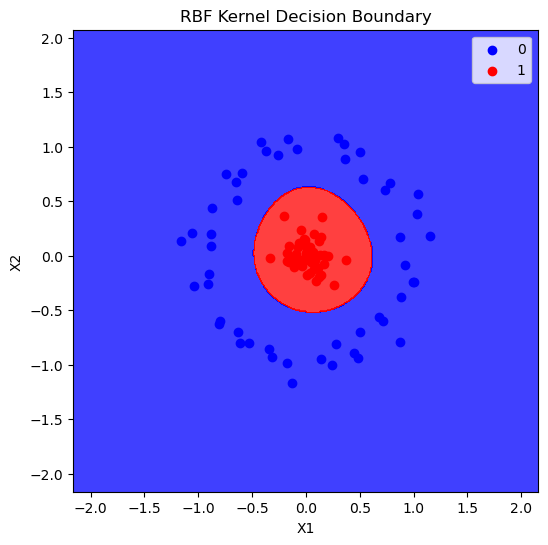

In [11]:
# ================================
# CELL 11 : RBF GRAPH
# ================================

plot_decision_boundary(
    X,
    y,
    rbf_classifier,
    "RBF Kernel Decision Boundary"
)

In [12]:
# ================================
# CELL 12 : POLYNOMIAL KERNEL SVM
# ================================

poly_classifier = SVC(
    kernel='poly',
    degree=2
)

poly_classifier.fit(X_train, y_train)

y_pred = poly_classifier.predict(X_test)

print(
    "Polynomial Kernel Accuracy :",
    accuracy_score(y_test, y_pred)
)

Polynomial Kernel Accuracy : 1.0


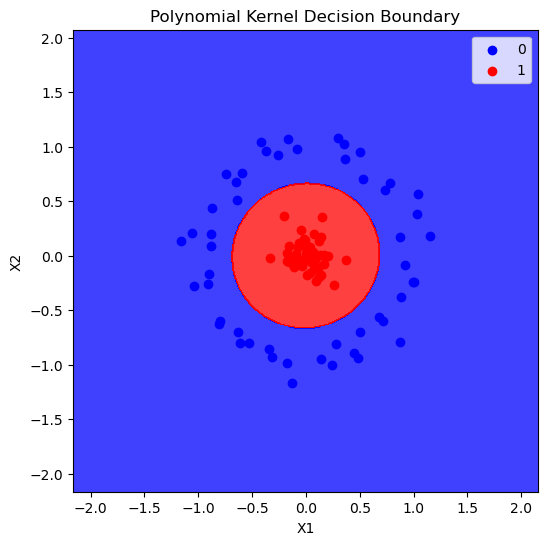

In [13]:
# ================================
# CELL 13 : POLYNOMIAL GRAPH
# ================================

plot_decision_boundary(
    X,
    y,
    poly_classifier,
    "Polynomial Kernel Decision Boundary"
)

In [14]:
# ================================
# CELL 14 : FEATURE TRANSFORMATION
# ================================

X_new = np.exp(-(X ** 2))

print(X_new[:5])

[[0.99989905 0.96980359]
 [0.98043074 0.97243827]
 [0.99643714 0.98605986]
 [0.59600121 0.6985267 ]
 [0.46434124 0.529878  ]]


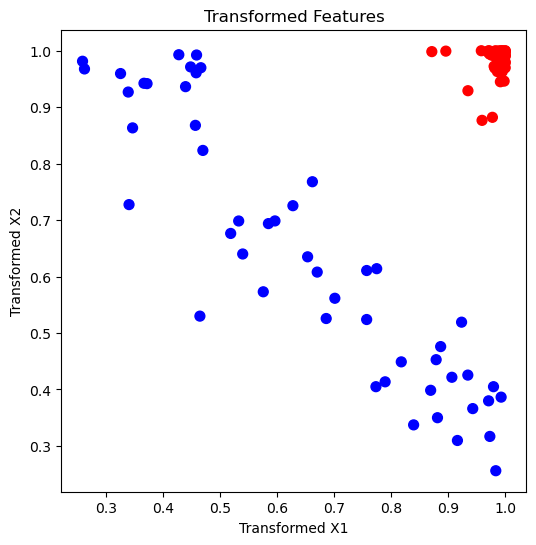

In [15]:
# ================================
# CELL 15 : TRANSFORMED FEATURES GRAPH
# ================================

plt.figure(figsize=(6,6))

plt.scatter(
    X_new[:, 0],
    X_new[:, 1],
    c=y,
    s=50,
    cmap='bwr'
)

plt.title("Transformed Features")
plt.xlabel("Transformed X1")
plt.ylabel("Transformed X2")

plt.show()